In [21]:
import os, json, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Cargar configuración
with open("../config.json") as f:
    config = json.load(f)

data_path = os.path.join("..", config["data"]["path"])
target = config["data"]["target_column"]

# Cargar datos
df = pd.read_csv(data_path)


In [22]:
print("Primeras filas:")
display(df.head())

print("Resumen de estructura:")
df.info()

print("Estadísticas generales:")
display(df.describe(include="all"))

print("Valores nulos por columna:")
print(df.isnull().sum())

print("Duplicados:")
print(df.duplicated().sum())


Primeras filas:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Resumen de estructura:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
Estadísticas generales:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
count,301,301.000000,301.000000,301.000000,301.000000,301,301,301,301.000000
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,195,261,NaN
mean,NaN,2013.627907,4.661296,7.628472,36947.205980,NaN,NaN,NaN,0.043189
std,NaN,2.891554,5.082812,8.644115,38886.883882,NaN,NaN,NaN,0.247915
min,NaN,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000
25%,NaN,2012.000000,0.900000,1.200000,15000.000000,NaN,NaN,NaN,0.000000
50%,NaN,2014.000000,3.600000,6.400000,32000.000000,NaN,NaN,NaN,0.000000
75%,NaN,2016.000000,6.000000,9.900000,48767.000000,NaN,NaN,NaN,0.000000


Valores nulos por columna:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64
Duplicados:
2


In [23]:
# Clasificación automática
categorical = df.select_dtypes(include="object").columns.tolist()
numerical = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Variables categóricas:", categorical)
print("Variables numéricas:", numerical)


Variables categóricas: ['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission']
Variables numéricas: ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']


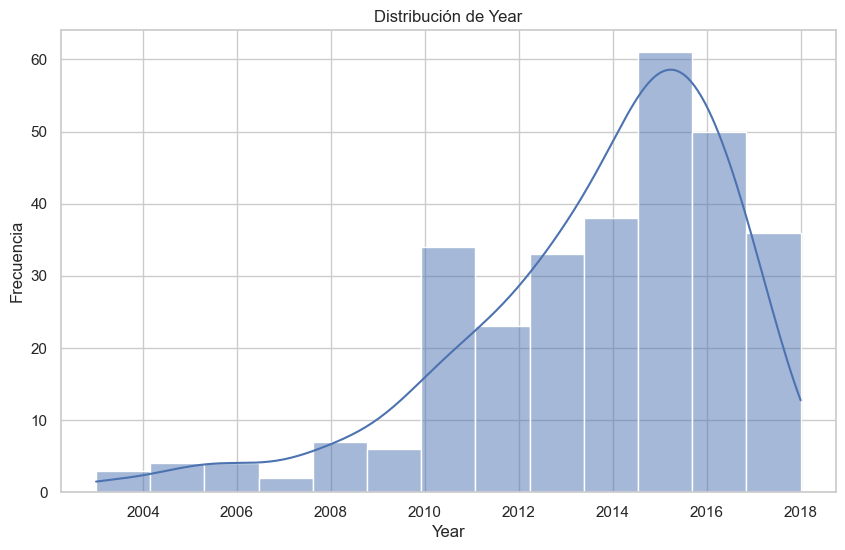

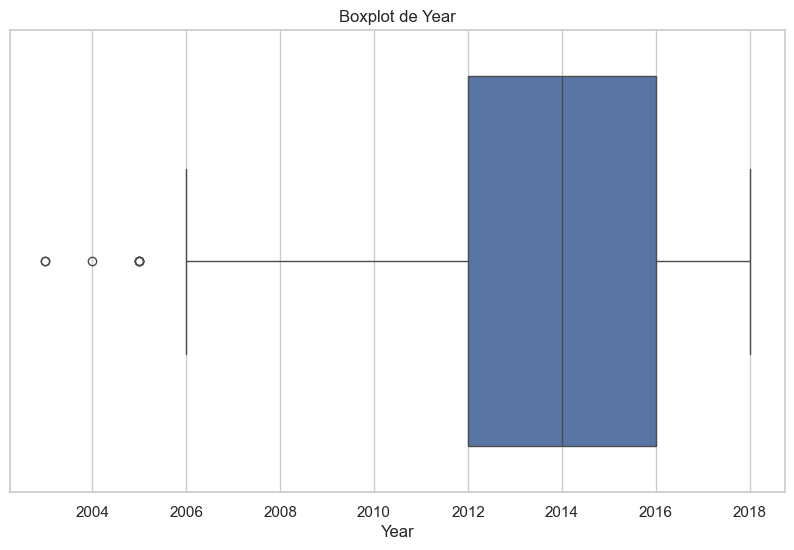

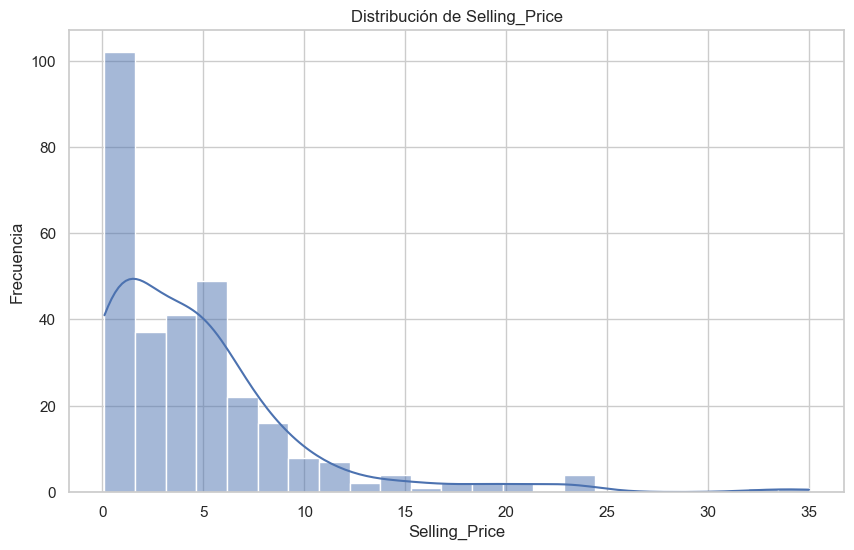

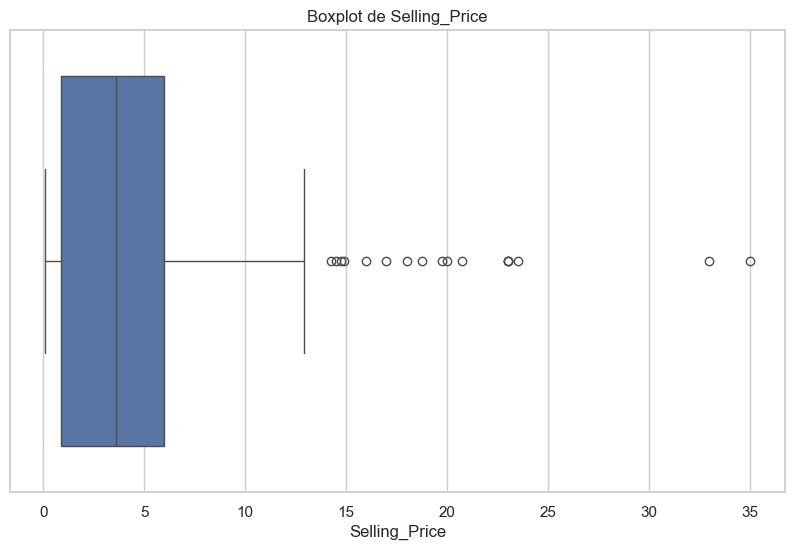

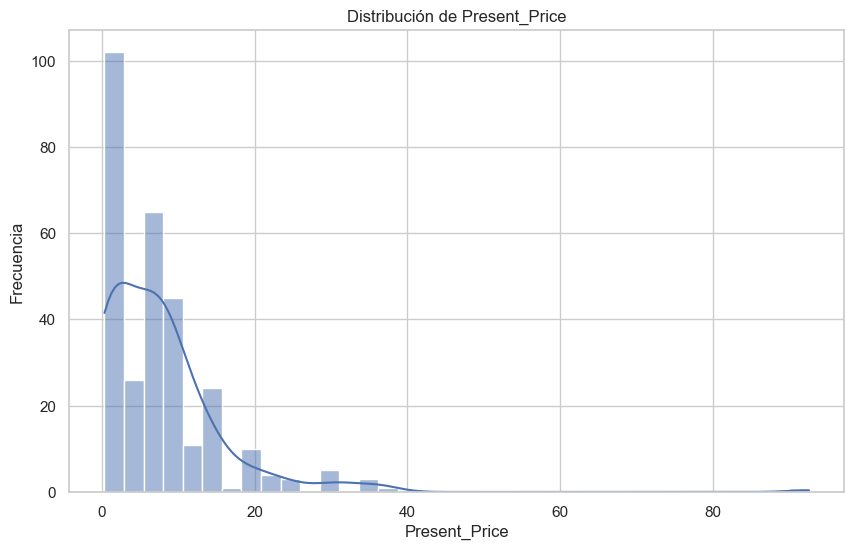

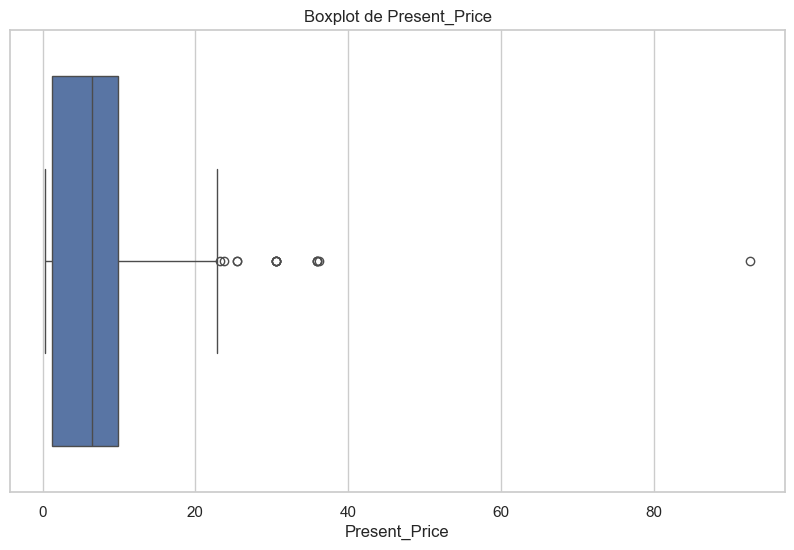

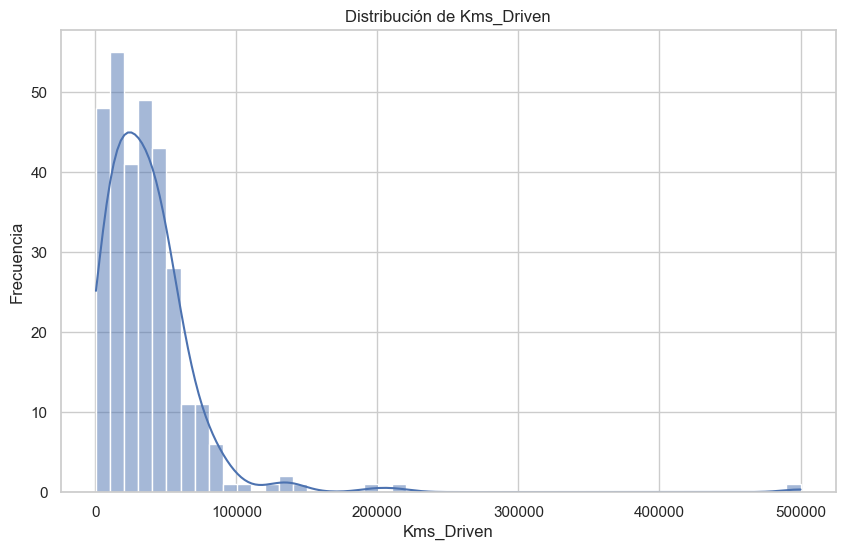

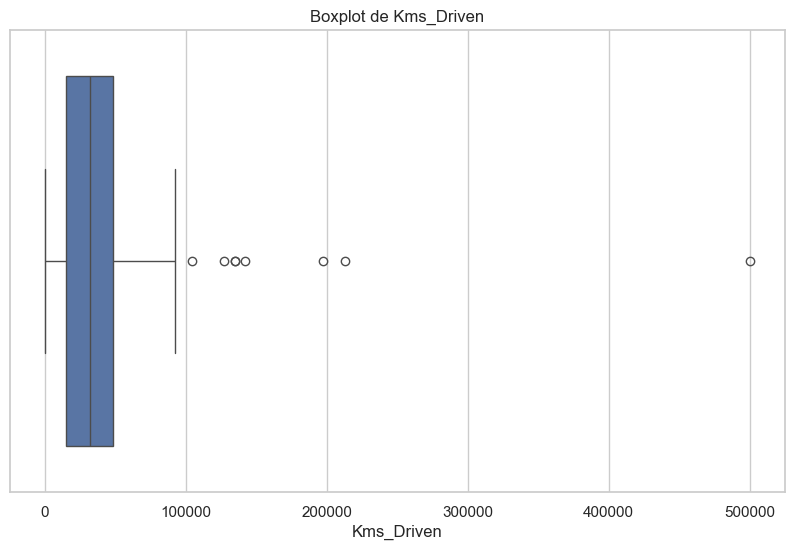

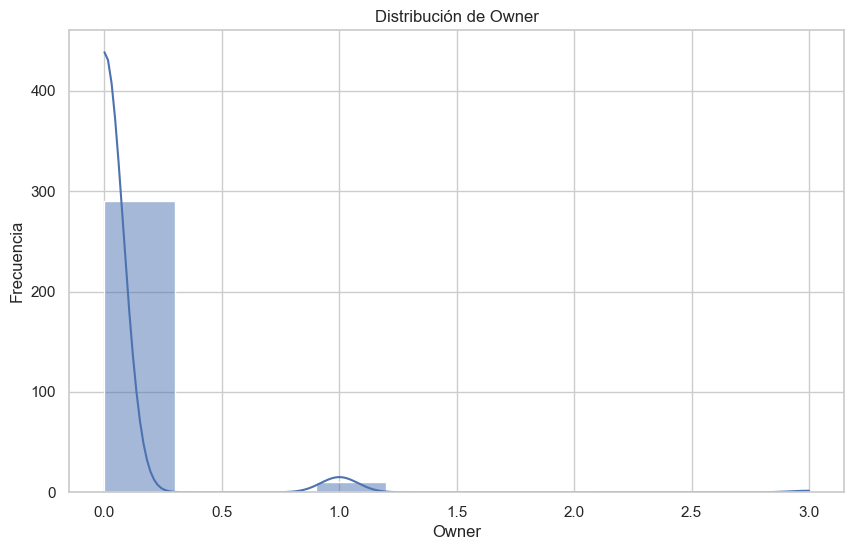

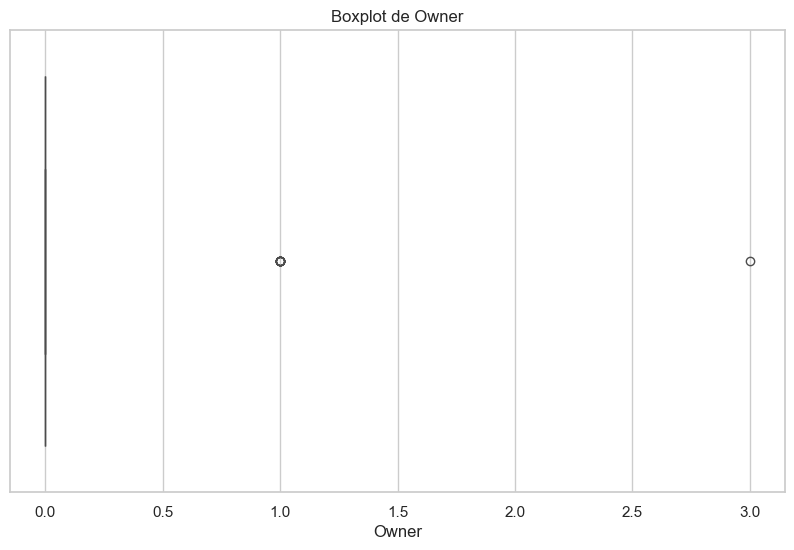

In [24]:
for col in numerical:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()


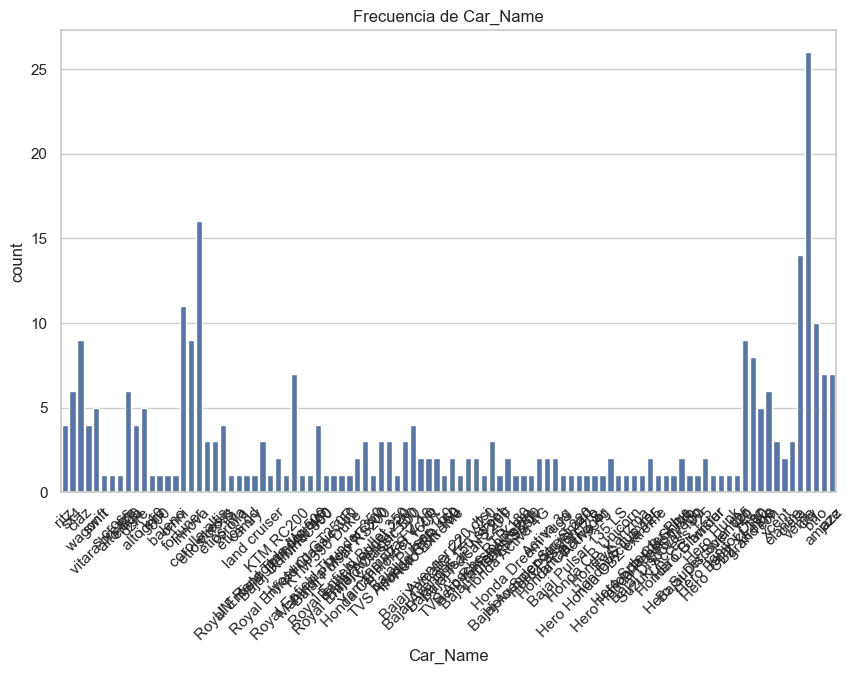

Value counts de Car_Name:
Car_Name
city                  26
corolla altis         16
verna                 14
fortuner              11
brio                  10
                      ..
Honda Activa 125       1
Hero Hunk              1
Hero  Ignitor Disc     1
Hero  CBZ Xtreme       1
Bajaj  ct 100          1
Name: count, Length: 98, dtype: int64


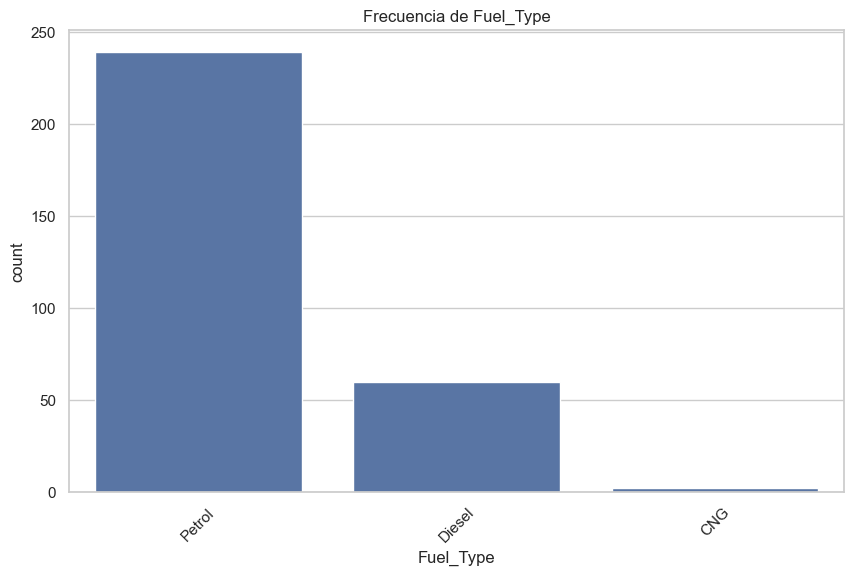

Value counts de Fuel_Type:
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64


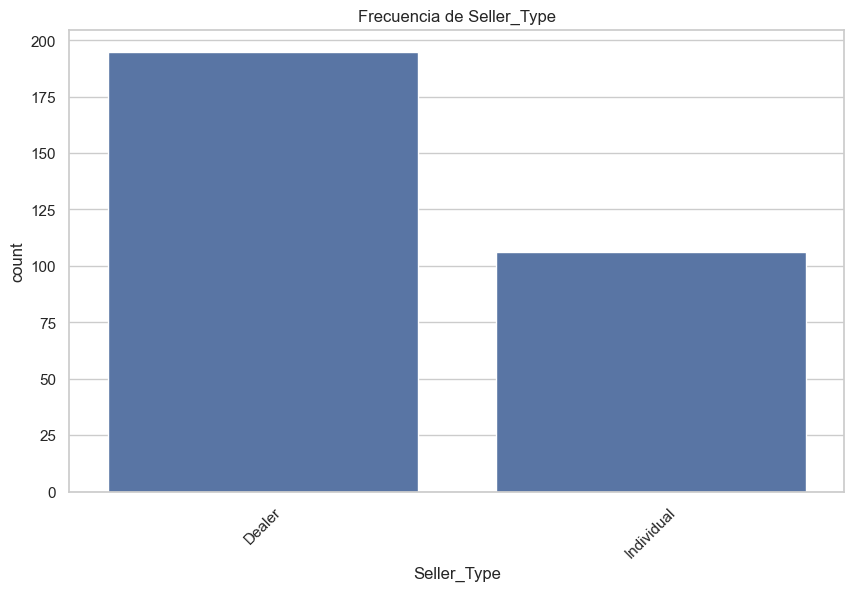

Value counts de Seller_Type:
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64


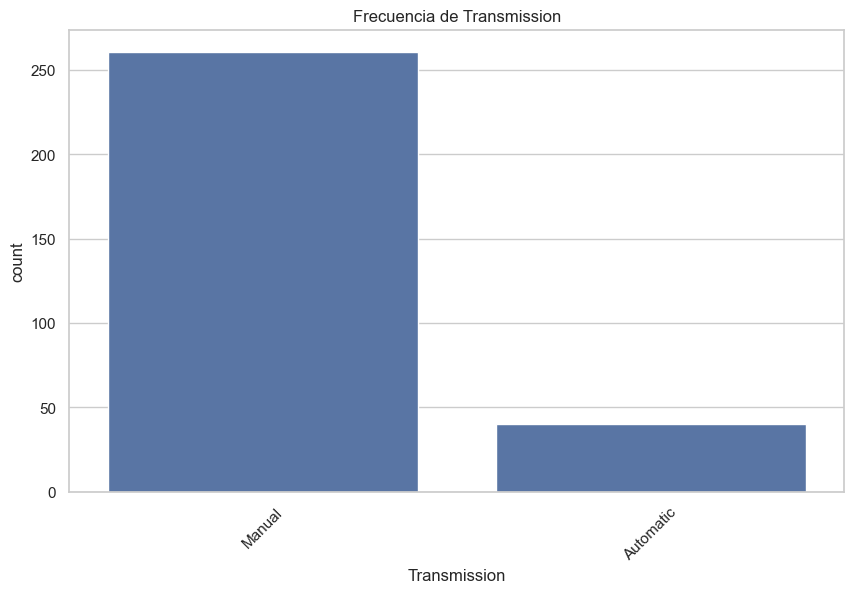

Value counts de Transmission:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [25]:
for col in categorical:
    sns.countplot(x=df[col])
    plt.title(f"Frecuencia de {col}")
    plt.xticks(rotation=45)
    plt.show()

    print(f"Value counts de {col}:")
    print(df[col].value_counts())


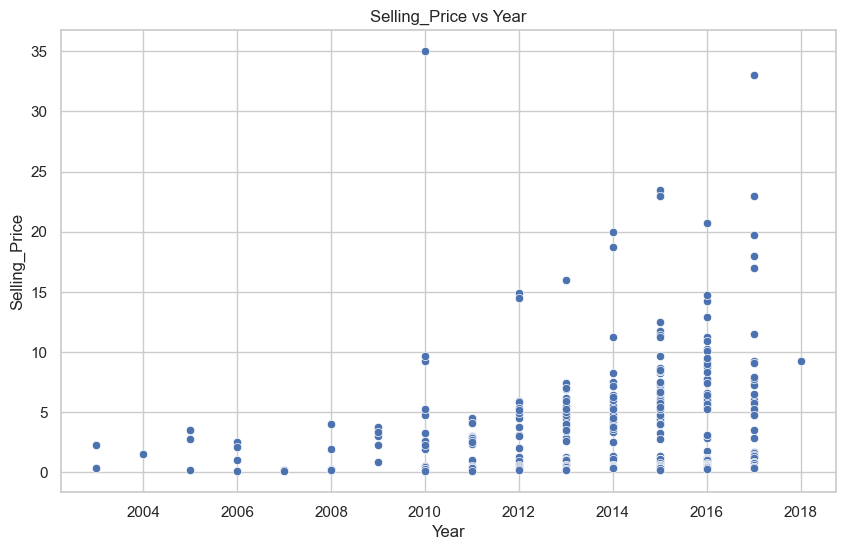

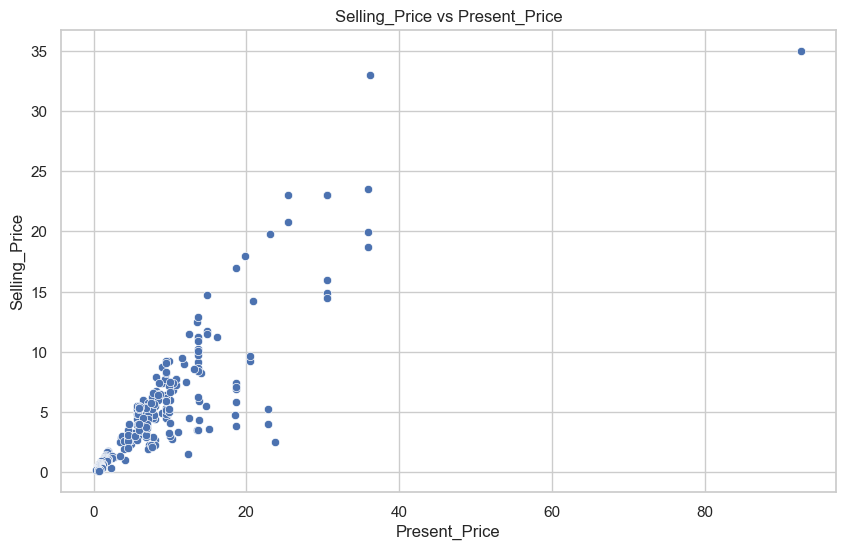

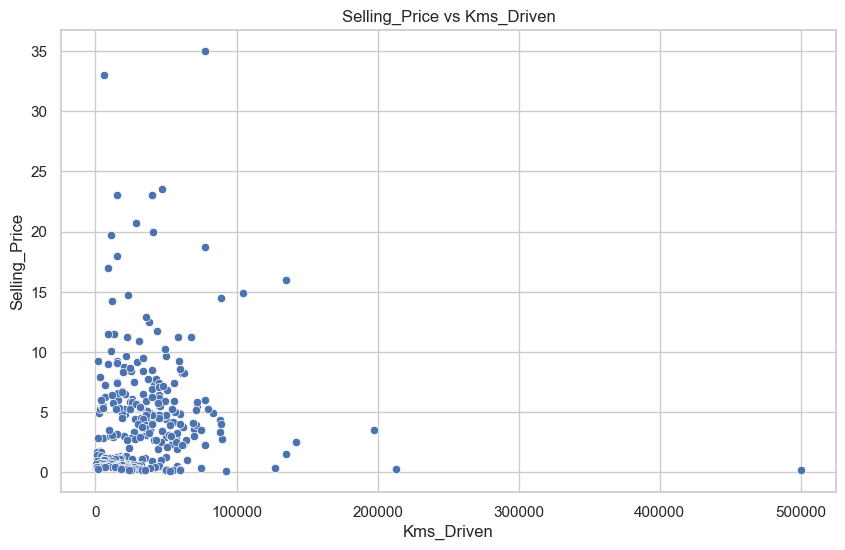

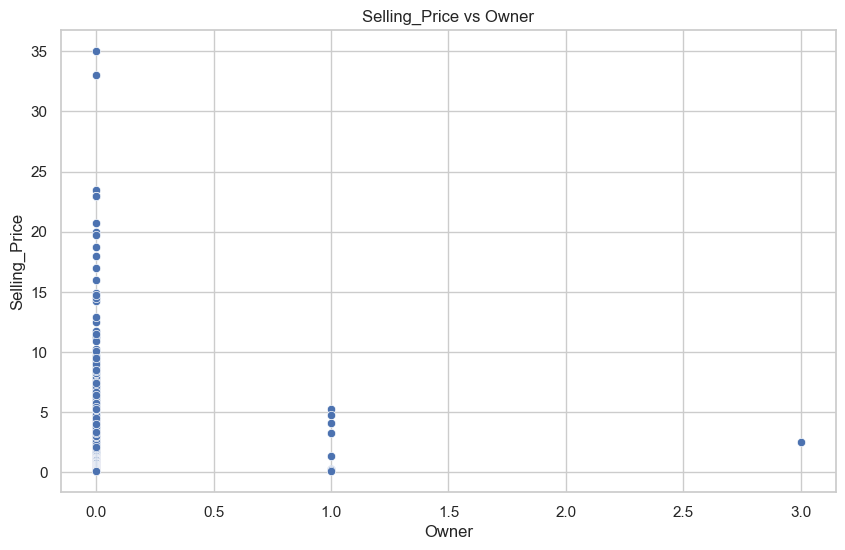

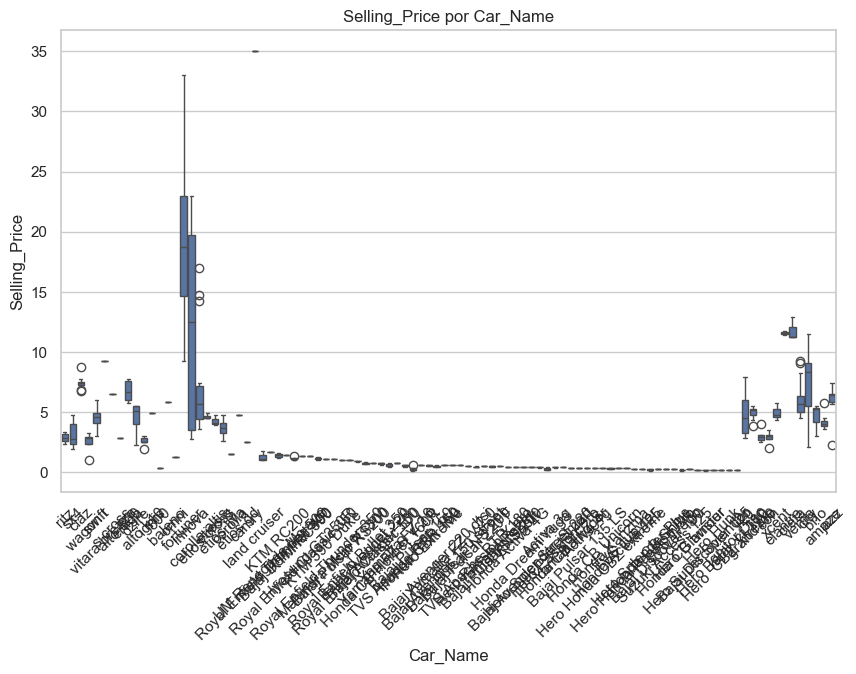

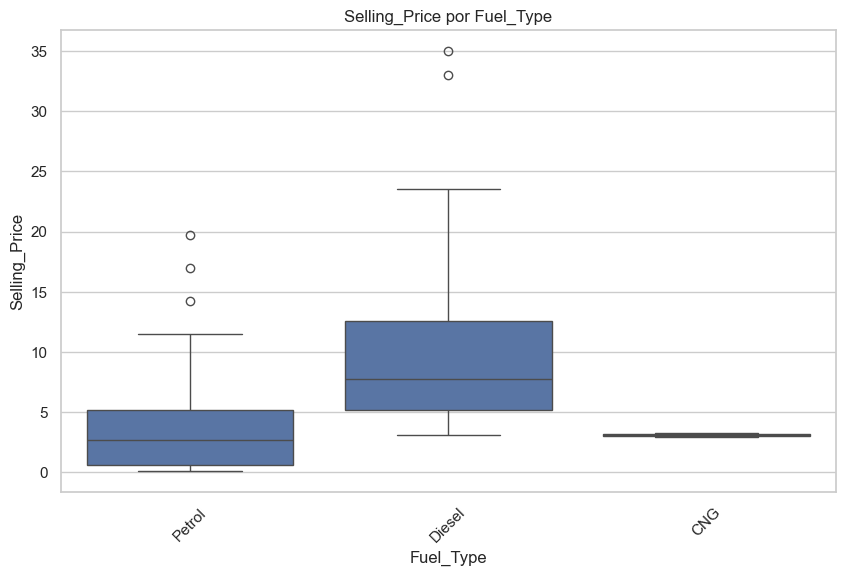

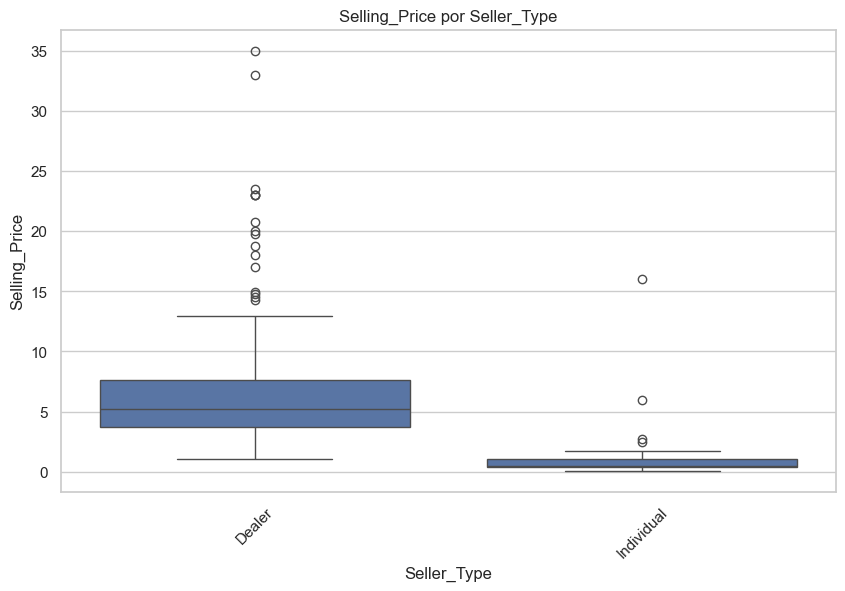

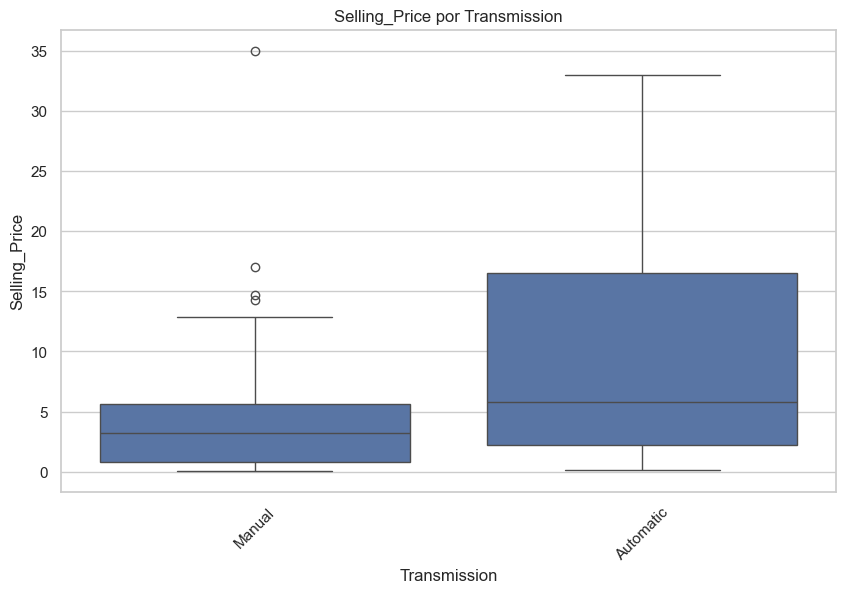

In [26]:
for col in numerical:
    if col != target:
        sns.scatterplot(x=df[col], y=df[target])
        plt.title(f"{target} vs {col}")
        plt.show()

for col in categorical:
    sns.boxplot(x=df[col], y=df[target])
    plt.title(f"{target} por {col}")
    plt.xticks(rotation=45)
    plt.show()


In [30]:
# Asegúrate de que target esté incluido como numérico
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

if target not in numerical_cols:
    numerical_cols.append(target)

# Verifica que todas las columnas estén en el DataFrame
print("Columnas usadas en pairplot:", numerical_cols)


Columnas usadas en pairplot: ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']


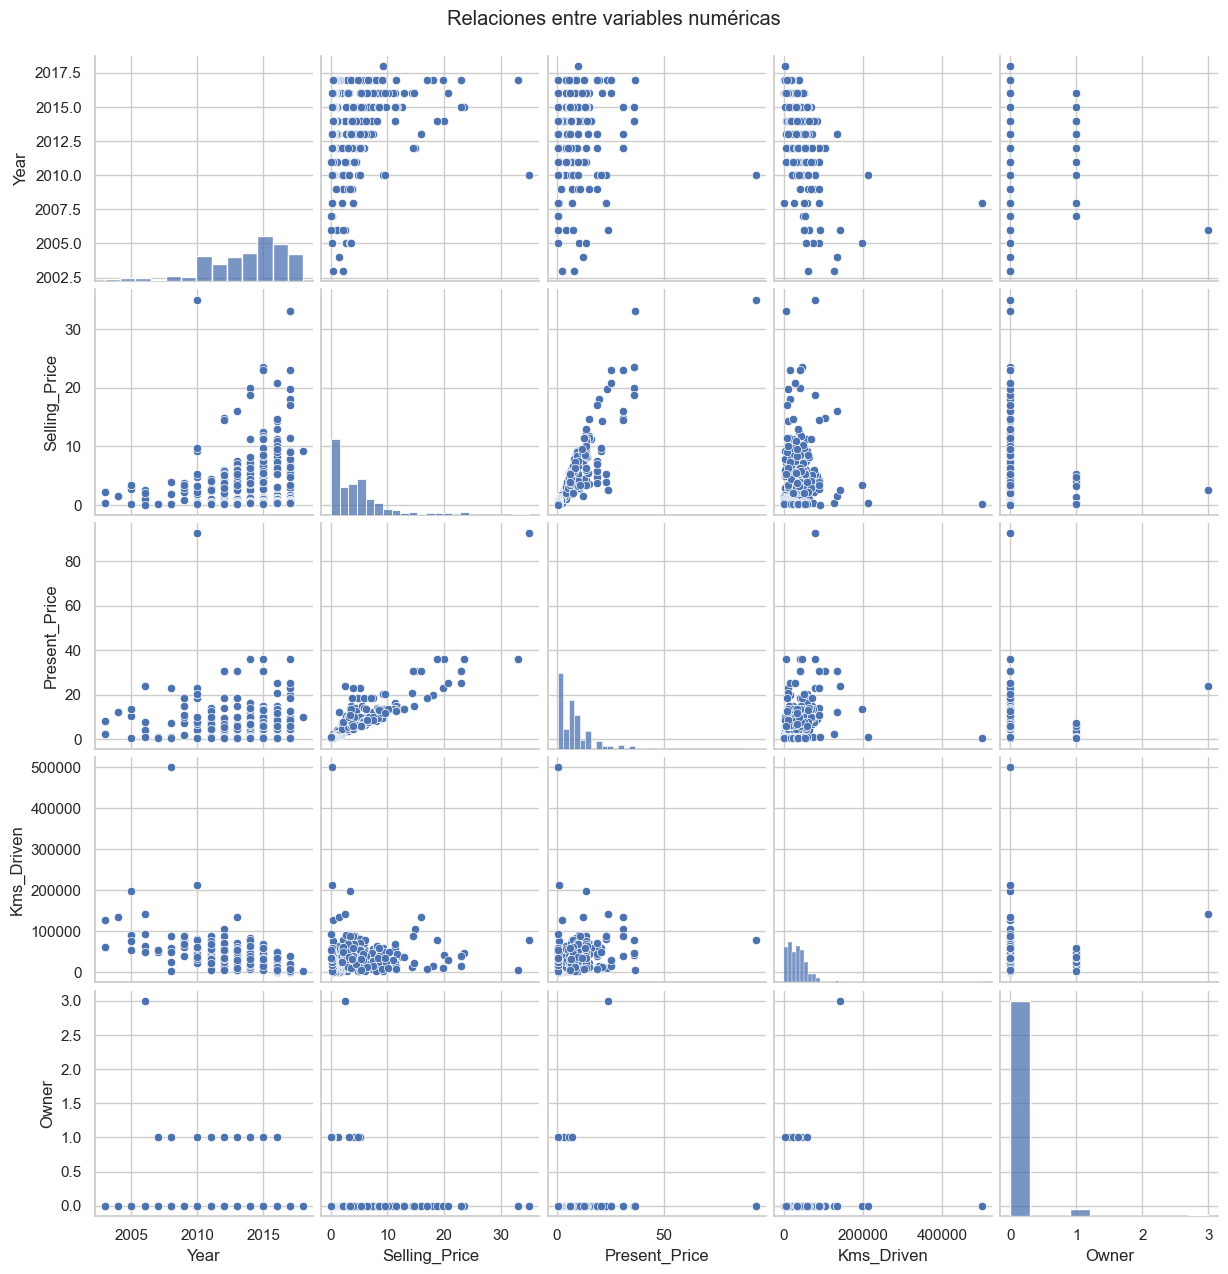

In [31]:
sns.pairplot(df[numerical_cols].dropna())
plt.suptitle("Relaciones entre variables numéricas", y=1.02)
plt.show()
